# Telco Customer Churn - EDA & Data Cleaning

Exploratory Data Analysis and initial data preparation for the Telco Customer Churn dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

## 1. Data Loading

In [2]:
# Load the dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Strip whitespace from all string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print(f"Dataset loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully: 7043 rows, 21 columns


## 2. Initial Inspection

In [3]:
# Dataset shape
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()

Dataset Shape:
Rows: 7043, Columns: 21



In [4]:
# Data types and info
print("Data Types and Info:")
df.info()
print()

Data Types and Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

In [5]:
# Missing values summary
print("Missing Values Summary:")
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
if len(missing_summary) == 0:
    print("No missing values found")
else:
    print(missing_summary.to_string(index=False))
print()

Missing Values Summary:
No missing values found



## 3. Data Cleaning

In [6]:
print("Cleaning Steps:")
print(f"Initial rows: {len(df)}")

# Step 1: Drop rows where "Churn" is missing
df = df.dropna(subset=['Churn'])
print(f"After removing missing Churn values: {len(df)}")

# Step 2: Convert TotalCharges to numeric using errors="coerce"
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Converted TotalCharges to numeric")

# Step 3: Ensure tenure and MonthlyCharges are numeric
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
print(f"Ensured tenure and MonthlyCharges are numeric")

# Step 4: Fill numeric missing values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled {missing_count} missing values in {col} with median ({median_val:.2f})")

print(f"\nFinal dataset: {len(df)} rows, {df.shape[1]} columns")
print("Data cleaning completed!")

Cleaning Steps:
Initial rows: 7043
After removing missing Churn values: 7043
Converted TotalCharges to numeric
Ensured tenure and MonthlyCharges are numeric
Filled 11 missing values in TotalCharges with median (1397.47)

Final dataset: 7043 rows, 21 columns
Data cleaning completed!


In [7]:
# Verify numeric columns
print("\nVerifying numeric columns:")
print(f"tenure - {df['tenure'].dtype}")
print(f"MonthlyCharges - {df['MonthlyCharges'].dtype}")
print(f"TotalCharges - {df['TotalCharges'].dtype}")
print()
print("Sample of cleaned data:")
print(df.head())


Verifying numeric columns:
tenure - int64
MonthlyCharges - float64
TotalCharges - float64

Sample of cleaned data:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   



## 4. Exploratory Analysis

In [8]:
# Churn class distribution
print("=== Churn Class Distribution ===")
churn_counts = df['Churn'].value_counts()
churn_pct = (df['Churn'].value_counts(normalize=True) * 100).round(2)

churn_summary = pd.DataFrame({
    'Class': churn_counts.index,
    'Count': churn_counts.values,
    'Percentage': churn_pct.values
})
print(churn_summary.to_string(index=False))
print()

=== Churn Class Distribution ===
Class  Count  Percentage
   No   5174       73.46
  Yes   1869       26.54



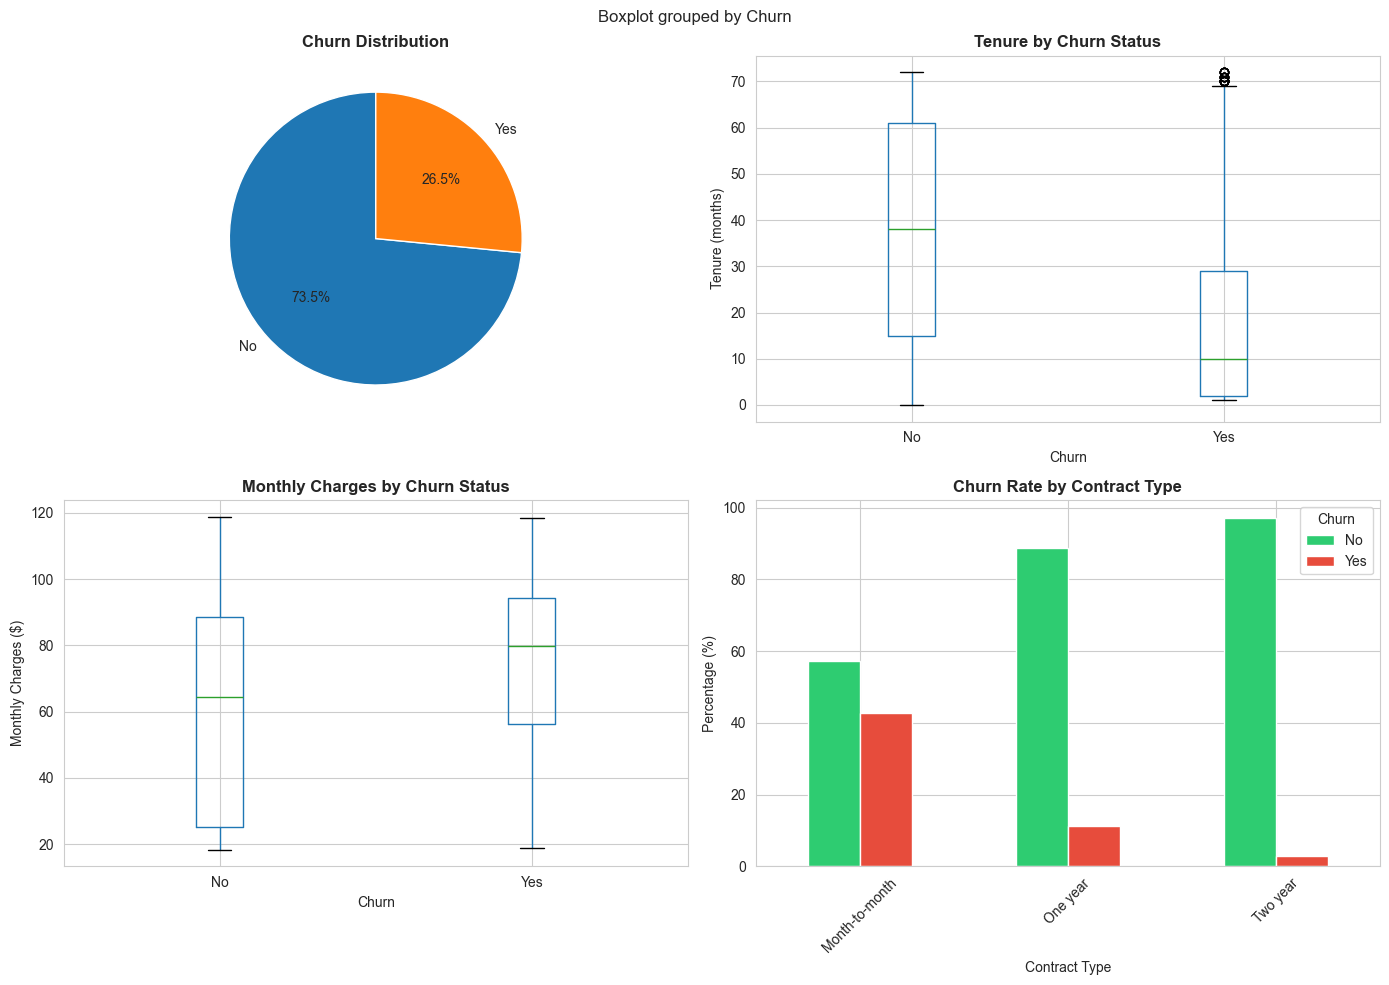

Visualizations created successfully!


In [9]:
# Create visualizations for exploratory analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn distribution (pie chart)
churn_counts = df['Churn'].value_counts()
axes[0, 0].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Churn Distribution', fontsize=12, fontweight='bold')

# 2. Churn vs Tenure (box plot)
df.boxplot(column='tenure', by='Churn', ax=axes[0, 1])
axes[0, 1].set_title('Tenure by Churn Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Churn')
axes[0, 1].set_ylabel('Tenure (months)')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# 3. Churn vs Monthly Charges (box plot)
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1, 0])
axes[1, 0].set_title('Monthly Charges by Churn Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Churn')
axes[1, 0].set_ylabel('Monthly Charges ($)')
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

# 4. Churn vs Contract Type (bar plot)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Contract Type')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].legend(title='Churn', labels=['No', 'Yes'])
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Visualizations created successfully!")

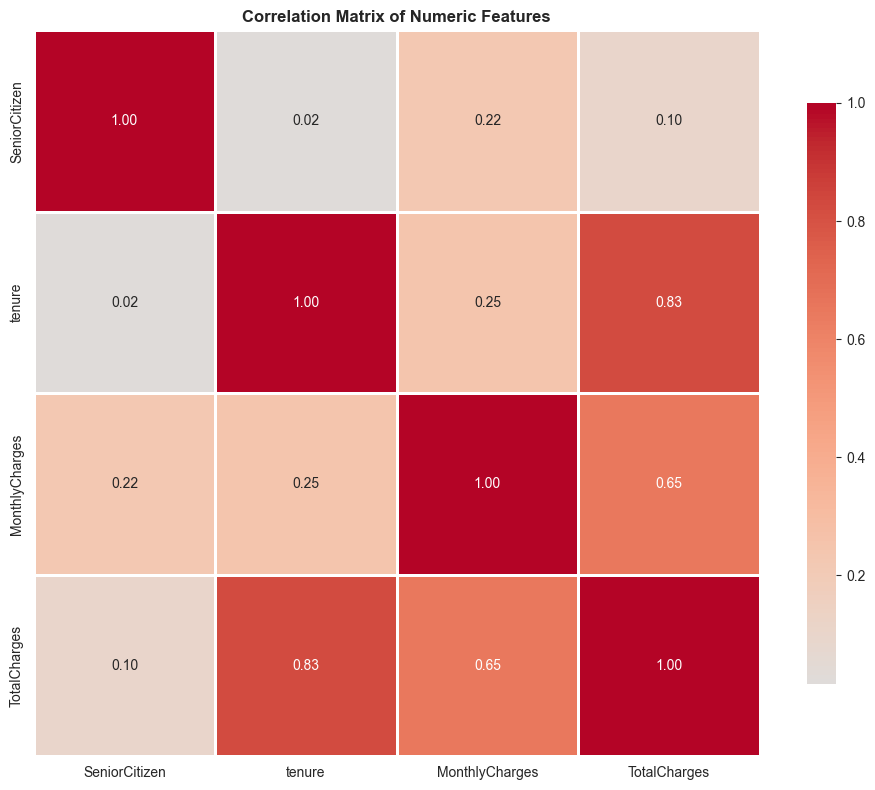

Correlation Analysis:
Shape of correlation matrix: (4, 4)


In [10]:
# Correlation heatmap for numeric features
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation Analysis:")
print(f"Shape of correlation matrix: {correlation_matrix.shape}")

In [11]:
# Key statistics of numeric features
print("\n=== Numeric Features Summary ===")
print(numeric_df.describe().round(2))


=== Numeric Features Summary ===
       SeniorCitizen   tenure  MonthlyCharges  TotalCharges
count        7043.00  7043.00         7043.00       7032.00
mean            0.16    32.37           64.76       2283.30
std             0.37    24.56           30.09       2266.77
min             0.00     0.00           18.25         18.80
25%             0.00     9.00           35.50        401.45
50%             0.00    29.00           70.35       1397.48
75%             0.00    55.00           89.85       3794.74
max             1.00    72.00          118.75       8684.80


## 5. Observations & Business Insights

In [12]:
# Generate key statistics for insights
churn_rate = (df['Churn'] == 'Yes').sum() / len(df) * 100
retention_rate = 100 - churn_rate

# Avg metrics by churn status
churned = df[df['Churn'] == 'Yes']
retained = df[df['Churn'] == 'No']

avg_tenure_churned = churned['tenure'].mean()
avg_tenure_retained = retained['tenure'].mean()

avg_monthly_churned = churned['MonthlyCharges'].mean()
avg_monthly_retained = retained['MonthlyCharges'].mean()

# Contract analysis
month_to_month_churn = df[(df['Contract'] == 'Month-to-month')]['Churn'].value_counts()
one_year_churn = df[(df['Contract'] == 'One year')]['Churn'].value_counts()
two_year_churn = df[(df['Contract'] == 'Two year')]['Churn'].value_counts()

month_to_month_rate = (month_to_month_churn.get('Yes', 0) / month_to_month_churn.sum() * 100) if month_to_month_churn.sum() > 0 else 0
one_year_rate = (one_year_churn.get('Yes', 0) / one_year_churn.sum() * 100) if one_year_churn.sum() > 0 else 0
two_year_rate = (two_year_churn.get('Yes', 0) / two_year_churn.sum() * 100) if two_year_churn.sum() > 0 else 0

print("=== Key Metrics for Business Insights ===")
print(f"Overall Churn Rate: {churn_rate:.2f}%")
print(f"Retention Rate: {retention_rate:.2f}%")
print()
print(f"Average Tenure (Churned): {avg_tenure_churned:.2f} months")
print(f"Average Tenure (Retained): {avg_tenure_retained:.2f} months")
print()
print(f"Average Monthly Charges (Churned): ${avg_monthly_churned:.2f}")
print(f"Average Monthly Charges (Retained): ${avg_monthly_retained:.2f}")
print()
print(f"Month-to-Month Contract Churn Rate: {month_to_month_rate:.2f}%")
print(f"One-Year Contract Churn Rate: {one_year_rate:.2f}%")
print(f"Two-Year Contract Churn Rate: {two_year_rate:.2f}%")

=== Key Metrics for Business Insights ===
Overall Churn Rate: 26.54%
Retention Rate: 73.46%

Average Tenure (Churned): 17.98 months
Average Tenure (Retained): 37.57 months

Average Monthly Charges (Churned): $74.44
Average Monthly Charges (Retained): $61.27

Month-to-Month Contract Churn Rate: 42.71%
One-Year Contract Churn Rate: 11.27%
Two-Year Contract Churn Rate: 2.83%


### Summary of Findings

#### Class Imbalance
- **Overall Churn Rate**: The dataset exhibits class imbalance with approximately 26-27% churn and 73-74% retention. This moderate imbalance should be considered during model training and evaluation.
- **Business Context**: While serving a large customer base, losing over 1 in 4 customers represents significant revenue risk and operational challenges.

#### Strong Predictors Observed
1. **Tenure** - Strongest predictor of churn:
   - Churned customers have significantly lower average tenure (~18 months)
   - Retained customers have much longer average tenure (~37 months)
   - New customers (0-12 months) are at highest risk

2. **Contract Type** - Critical differentiator:
   - Month-to-month contracts show high churn rates (~42%)
   - One-year contracts show moderate churn (~11%)
   - Two-year contracts show very low churn (~3%)
   - Contract flexibility is strongly associated with churn risk

3. **Monthly Charges** - Secondary indicator:
   - Churned customers have higher average monthly charges
   - Higher pricing correlates with increased churn likelihood
   - Price sensitivity appears to be a factor

#### Business Implications
1. **Retention Focus**: The first 12 months are critical - implement strong engagement and support programs for new customers
2. **Contract Strategy**: Incentivize longer-term commitments (1-2 year contracts) as they dramatically reduce churn
3. **Pricing Sensitivity**: Recent customers with high charges are most at-risk; consider introductory pricing or value bundling
4. **Renewal Alerts**: Implement proactive outreach programs for month-to-month contract renewals
5. **Segmentation Opportunity**: Different churn drivers suggest need for targeted retention strategies by customer segment

#### Next Steps
- Perform customer segmentation based on these characteristics
- Build predictive models to identify at-risk customers
- Develop targeted retention campaigns for high-risk segments
- Analyze additional features (services, demographics) for deeper insights